In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Import du dataset

In [68]:
import glob

files = glob.glob("../data/eCO2mix_RTE_Annuel-Definitif_*.xls")

dfs = []
for f in files:
    df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

C:\Users\trist\AppData\Local\Temp\ipykernel_26464\2610033358.py:7: DtypeWarning: Columns (0: Ech. comm. Angleterre, 1: Ech. comm. Espagne, 2: Ech. comm. Italie, 3: Ech. comm. Suisse, 4: Ech. comm. Allemagne-Belgique) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f, sep="\t", encoding="latin-1", index_col=False)
C:\Users\trist\AppData\Local\Temp\ipykernel_26464\2610033358.py:7: DtypeWarning: Columns (0: Ech. comm. Angleterre, 1: Ech. comm. Espagne, 2: Ech. comm. Italie, 3: Ech. comm. Suisse, 4: Ech. comm. Allemagne-Belgique, 5: Fioul - TAC, 6: Fioul - Cogén., 7: Fioul - Autres, 8: Gaz - TAC, 9: Gaz - Cogén., 10: Gaz - CCG, 11: Gaz - Autres, 12: Hydraulique - Fil de l?eau + éclusée, 13: Hydraulique - Lacs, 14: Hydraulique - STEP turbinage, 15: Bioénergies - Déchets, 16: Bioénergies - Biomasse, 17: Bioénergies - Biogaz) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(f, sep="\t", encoding

## Exploration

In [69]:
df.head(10)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2012-01-01,00:00,58315.0,58200.0,58200.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
1,France,Données définitives,2012-01-01,00:15,NaN,57700.0,57550.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Données définitives,2012-01-01,00:30,58315.0,57200.0,56900.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
3,France,Données définitives,2012-01-01,00:45,NaN,56200.0,56000.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,France,Données définitives,2012-01-01,01:00,56231.0,55200.0,55100.0,492.0,25.0,3834.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
5,France,Données définitives,2012-01-01,01:15,NaN,55600.0,55250.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,France,Données définitives,2012-01-01,01:30,56075.0,56000.0,55400.0,491.0,25.0,3832.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
7,France,Données définitives,2012-01-01,01:45,NaN,56000.0,55200.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,France,Données définitives,2012-01-01,02:00,55532.0,56000.0,55000.0,492.0,25.0,3839.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
9,France,Données définitives,2012-01-01,02:15,NaN,55750.0,54300.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# On retire les données au pas 00:15 et 00:45 car les données définitives fonctionnent par pas de 30 minutes
df = df.dropna(subset=["Consommation"])

In [71]:
df.head(10)

,Périmètre,Nature,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,...,Hydraulique - Fil de l?eau + éclusée,Hydraulique - Lacs,Hydraulique - STEP turbinage,Bioénergies - Déchets,Bioénergies - Biomasse,Bioénergies - Biogaz,Stockage batterie,Déstockage batterie,Eolien terrestre,Eolien offshore
0,France,Données définitives,2012-01-01,00:00,58315.0,58200.0,58200.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
2,France,Données définitives,2012-01-01,00:30,58315.0,57200.0,56900.0,492.0,25.0,3816.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
4,France,Données définitives,2012-01-01,01:00,56231.0,55200.0,55100.0,492.0,25.0,3834.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
6,France,Données définitives,2012-01-01,01:30,56075.0,56000.0,55400.0,491.0,25.0,3832.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
8,France,Données définitives,2012-01-01,02:00,55532.0,56000.0,55000.0,492.0,25.0,3839.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
10,France,Données définitives,2012-01-01,02:30,54911.0,55500.0,53600.0,492.0,26.0,3836.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
12,France,Données définitives,2012-01-01,03:00,52496.0,52400.0,51100.0,494.0,25.0,3836.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
14,France,Données définitives,2012-01-01,03:30,50664.0,50800.0,49200.0,491.0,24.0,3818.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
16,France,Données définitives,2012-01-01,04:00,49161.0,49100.0,47600.0,492.0,24.0,3824.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN
18,France,Données définitives,2012-01-01,04:30,47596.0,47800.0,46400.0,492.0,24.0,3822.0,...,ND,ND,ND,ND,ND,ND,NaN,NaN,NaN,NaN


In [72]:
df.describe()

,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,Taux de Co2
count,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000,227952.000000
mean,53182.062623,52745.233584,52674.724126,247.414763,773.723512,3345.550502,42387.903883,3413.601587,1346.135752,7154.372289,-783.641214,1017.790153,-5697.829346,42.275475
std,11806.156756,11796.397380,11775.292130,271.402821,1072.873358,2470.652257,7774.930696,3079.281338,2280.409705,2811.745630,984.664228,188.491789,4806.132133,23.235210
min,29124.000000,27500.000000,0.000000,18.000000,0.000000,234.000000,19164.000000,21.000000,0.000000,1387.000000,-4086.000000,441.000000,-20083.000000,7.000000
25%,44257.750000,43800.000000,43900.000000,87.000000,15.000000,1017.000000,37806.000000,1266.000000,0.000000,5007.750000,-1467.000000,901.000000,-9109.000000,24.000000
50%,51410.000000,51000.000000,50900.000000,146.000000,316.000000,2881.000000,41950.000000,2388.000000,20.000000,6932.000000,-207.000000,1071.000000,-6234.000000,38.000000
75%,61042.000000,60500.000000,60400.000000,326.000000,1192.000000,4956.250000,47327.250000,4524.000000,1916.000000,9025.000000,-21.000000,1153.000000,-2982.000000,57.000000
max,102098.000000,101000.000000,102700.000000,5926.000000,6265.000000,10591.000000,61712.000000,19744.000000,16658.000000,17947.000000,-1.000000,3252.000000,14608.000000,141.000000


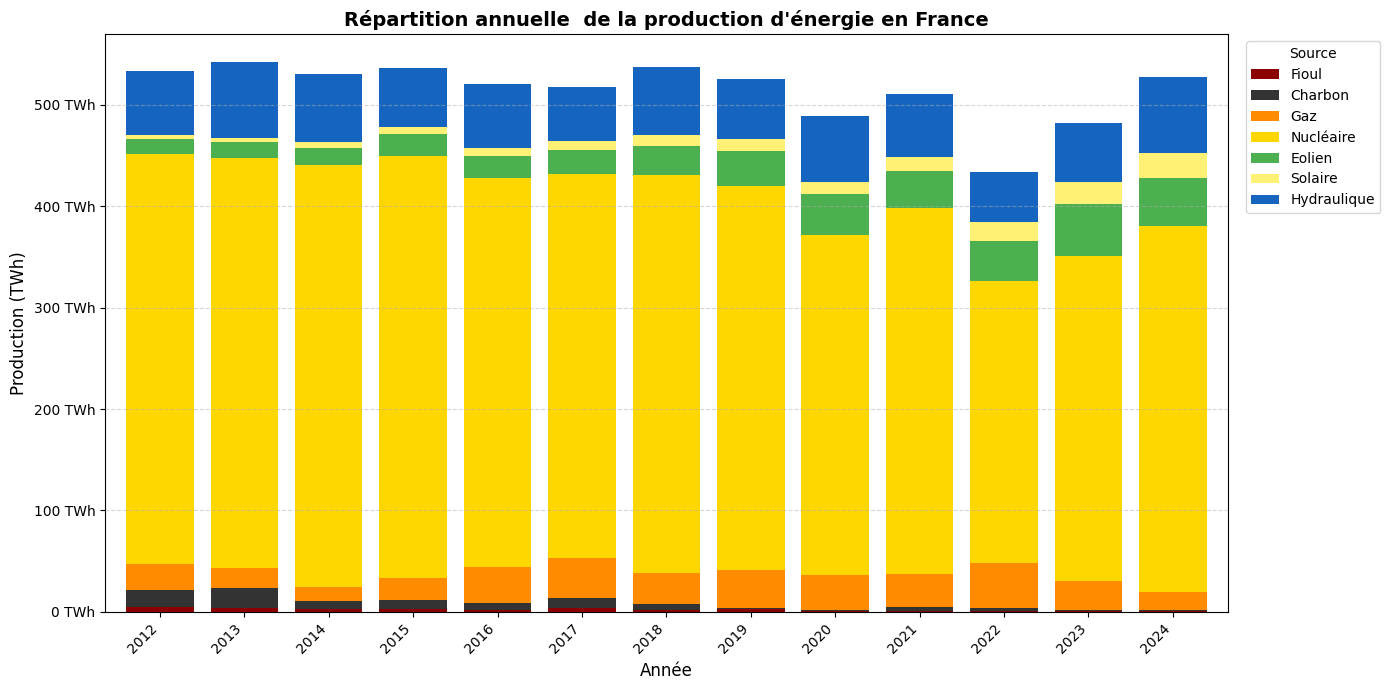

In [ ]:
df_explo = df.copy()

df_explo["Date"] = pd.to_datetime(df_explo["Date"])
df_explo["Année"] = df_explo["Date"].dt.to_period("Y")

energy_cols = ["Fioul", "Charbon", "Gaz", "Nucléaire", "Eolien", "Solaire", "Hydraulique"]

annually = df_explo.groupby("Année")[energy_cols].sum() * 0.5 # 0.5 pour remettre en heure car nous avons des relevés toutes les 30 minutes

# Convertir en TWh pour lisibilité
annually_twh = annually / 1e6

fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#8B0000", "#333333", "#FF8C00", "#FFD700", "#4CAF50", "#FFF176", "#1565C0"]

annually_twh.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8)

ax.set_title("Répartition annuelle de la production d'énergie en France", fontsize=14, fontweight="bold")
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Production (TWh)", fontsize=12)
ax.set_xticklabels([str(m) for m in annually_twh.index], rotation=45, ha="right")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} TWh"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

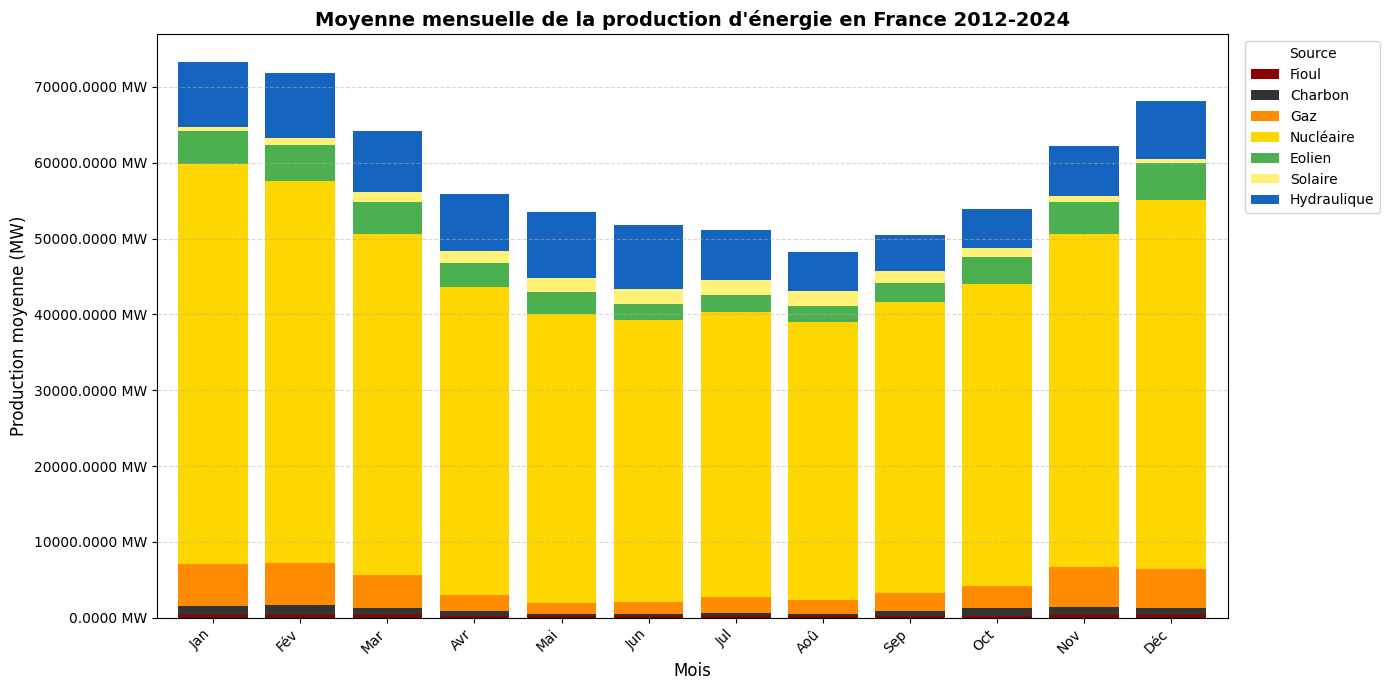

In [94]:
df_explo["Mois"] = df_explo["Date"].dt.month

monthly_avg = df_explo.groupby("Mois")[energy_cols].mean()

month_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(figsize=(14, 7))

monthly_avg.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8)

ax.set_title("Moyenne mensuelle de la production d'énergie en France 2012-2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Production moyenne (MW)", fontsize=12)
ax.set_xticklabels(month_labels, rotation=45, ha="right")
ax.legend(title="Source", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.4f} MW"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Datacard

In [74]:
from datetime import datetime
import yaml

In [75]:
n = len(df)

datacard = {
    "name": "eCO2mix_RTE_Annuel-Definitif",
    "version": "1.0",
    "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "domain": "energy",
    "period": "2012-2024",
    "data": {
        "instance_count": n,
        "feature_count": df.shape[1],
        "feature_list": {},
    }
}

description = {
    "Périmètre": "France",
    "Nature": "Données temps réel / Données consolidées / Données définitives",
    "Date": "Date du jour (jj/mm/aaaa)",
    "Heures": "Point horaire par pas de 30 minutes (hh:mm)",
    "Consommation": "Consommation en MW",
    "Prévision J-1": "Prévision J-1 de consommation en MW",
    "Prévision J": "Prévision J de consommation en MW",
    "Fioul": "Production fioul en MW",
    "Charbon": "Production charbon en MW",
    "Gaz": "Production gaz en MW",
    "Nucléaire": "Production nucléaire en MW",
    "Eolien": "Production éolienne en MW",
    "Solaire": "Production solaire en MW",
    "Hydraulique": "Production hydraulique en MW",
    "Pompage": "Pompage hydraulique en MW",
    "Bioénergies": "Production Bioénergies en MW",
    "Ech. physiques": "Solde imports/exports (flux physiques) en MW",
    "Taux de CO2": "Estimation des émissions de CO2 en g/kWh",
    "Ech. comm. Angleterre": "Solde imports/exports Angleterre (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Espagne": "Solde imports/exports Espagne (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Italie": "Solde imports/exports Italie (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Suisse": "Solde imports/exports Suisse (programmes d'échanges commerciaux) en MW",
    "Ech. comm. Allemagne-Belgique": "Solde imports/exports Allemagne-Belgique (programmes d'échanges commerciaux) en MW",
    "Fioul - TAC": "Détail technologie turbine à combustion pour la filière fioul",
    "Fioul - Cogén.": "Détail technologie cogénération pour la filière fioul",
    "Fioul - Autres": "Détail autres technologies pour la filière fioul",
    "Gaz - TAC": "Détail technologie turbine à combustion pour la filière gaz",
    "Gaz - Cogén.": "Détail technologie cogénération pour la filière gaz",
    "Gaz - CCG": "Détail technologie cycle combiné gaz pour la filière gaz",
    "Gaz - Autres": "Détail autres technologies pour la filière gaz",
    "Hydraulique - Fil de l'eau + éclusée": "Détail technologie fil de l'eau et éclusée pour la filière hydraulique",
    "Hydraulique - Lacs": "Détail technologie lacs pour la filière hydraulique",
    "Hydraulique - STEP turbinage": "Détail technologie STEP turbinage pour la filière hydraulique",
    "Bioénergies - Déchets": "Détail technologie déchets pour la filière Bioénergies",
    "Bioénergies - Biomasse": "Détail technologie biomasse pour la filière Bioénergies",
    "Bioénergies - Biogaz": "Détail technologie biogaz pour la filière Bioénergies",
    "Stockage batterie": "Détail soutirage batteries",
    "Déstockage batterie": "Détail injections batteries",
    "Eolien terrestre": "Détail technologie éolien terrestre pour la filière Eolien",
    "Eolien offshore": "Détail technologie éolien en mer pour la filière Eolien",
}

count = df.count()
nunique = df.nunique()
missing = df.isna().sum()

df_stats = pd.DataFrame({
    "count": count.astype(int),
    "unique_count": nunique.astype(int),
    "duplicate_count": (count - nunique).astype(int),
    "duplicate_ratio": ((count - nunique) / count).round(2).astype(float),
    "missing_count": missing.astype(int),
    "missing_ratio": (missing / n).round(2).astype(float),
})
describe = df.describe().astype(float)

for idx, row in df_stats.iterrows():
    card = {
        "description": description.get(idx, ""),
        "type": str(df[idx].dtypes),
        "stats": row.to_dict(),
        "sample": df[idx].dropna().unique()[:5].tolist()
    }

    if pd.api.types.is_numeric_dtype(df[idx]):
        card.update({
            'stats': {
                **row.to_dict(),
                **describe[idx].to_dict()
            }
        })

    datacard["data"]["feature_list"][idx] = card

In [76]:
with open("../data/raw_data.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(datacard, f, sort_keys=False, allow_unicode=True)